# **Proyecto de Regresión: Predicción de Precios de Vehículos**
##### Realizado por: *Coutiño Morales Francisco José*
***

## **Análisis del Problema**

### **Objetivo**
El objetivo es predecir el precio de venta (`selling_price`) de coches usados basándonos en características como la antigüedad del vehículo, el kilometraje, el tipo de combustible, el tipo de vendedor, y otras variables proporcionadas en el dataset.

### **Panorama**
Utilizaremos el dataset "Vehicle Dataset from Car dekho". Este conjunto de datos contiene detalles de coches usados y una columna etiquetada (`selling_price`) que es nuestro objetivo (target).

Utilizaremos un **sistema de aprendizaje supervisado** (Supervised Learning) porque estamos entrenando el modelo con ejemplos etiquetados. Específicamente, enfrentamos un problema de **Regresión Múltiple**, ya que utilizaremos múltiples características para predecir un valor numérico continuo.

### **Métrica de Evaluación**
Para evaluar nuestros modelos, utilizaremos el **Error Absoluto Medio (MAE)** para tener una idea clara del error en la moneda original, y el **Coeficiente de Determinación ($R^2$)** para ver qué tan bien se ajusta el modelo a la varianza de los datos.

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

***


## Fase 1: Importe del Dataset, inspeccion y analisis inicial 
    Como primera fase para poder manejar y trabajar en el programa con la iformacion correcta he cargado los datos, inspeccionado las primeras filas (df.head()), visto el tamaño (df.shape), revisado los nombres de las columnas (df.columns), y,  verificado la presencia de valores nulos (df.isnull().sum()), para posteriormente realizar un analisis grafico de la informacion y empezar a trabajar.

In [1]:
import pandas as pd

df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv") # Cargue los datos al programa
df.head() # Revisión de las primeras filas 

df.shape # Revisión del tamaño

df.columns # Revisión de los nombres de las columnas

df.isnull().sum() # Verificción la presencia de valores nulos







name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

## Análisis Exploratorio de Datos (EDA)
Antes de modificar los datos hare uso de graficas para facilitar y ayudar en el analisis y la comprensión de los datos para identificar patrones y anomalías.

### 1. Distribución de la Variable Objetivo (`selling_price`)
Analizamos el precio de venta mediante un **Histograma con Curva de Densidad (KDE)** porque necesitamos verificar la **normalidad** de los datos para SVR.

**Verificación de Normalidad para SVR:**
    El algoritmo que utilizaré más adelante, **SVR (Support Vector Regressor)**, se basa en cálculos de distancia y asume cierta regularidad en los datos.Si el histograma muestra que los precios tienen un rango muy amplio (de miles a millones) y una distribución no normal, esto **justifica obligatoriamente el uso de `StandardScaler`** en la Fase 2. Sin estandarización, el modelo SVR no puede o podría converger o daría un mal resultado.
    
* **Detección de Sesgo (Skewness) en Mercados Económicos:**
    En mercados económicos, es común ver un **sesgo a la derecha** (muchos autos económicos, pocos de lujo). Si el sesgo es muy fuerte, los modelos de regresión lineal podrían tener un rendimiento pobre sin una transformación logarítmica previa.
    Una cola muy larga nos advierte que el promedio (media) no es representativo. Esto nos ayuda a entender por qué métricas como el $R^2$ podrían ser bajas si no tratamos estos valores atípicos.

* **Detección de Outliers (Valores Atípicos):**
    Visualizar barras aisladas en el extremo derecho nos indica la presencia de *outliers*. Esto valida la decisión de usar modelos robustos (como Random Forest en la iteración) o técnicas de escalado en una fase posterior.


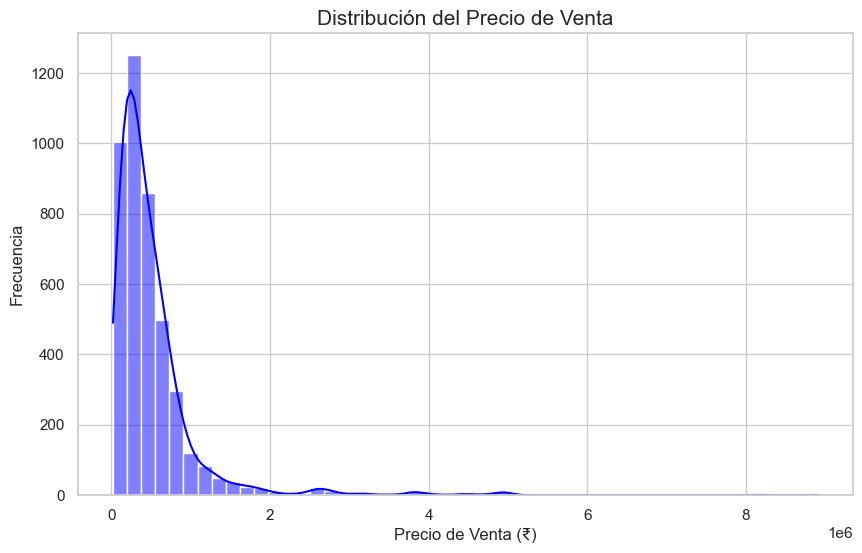

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df['selling_price'], kde=True, color='blue', bins=50)
plt.title('Distribución del Precio de Venta', fontsize=15)
plt.xlabel('Precio de Venta (₹)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

### 2. Relación Bivariada: Kilometraje vs. Precio

Una vez entendida la variable objetivo, analizamos cómo las variables predictoras (features) pueden influir en ella. Utilizamos un **Gráfico de Dispersión (Scatter Plot)** para visualizar la relación entre `km_driven` y `selling_price`.

**Justificación y Conexión con el Modelado:**

* **Validación de Hipótesis (Correlación Negativa):**
    Como sabemos que un factor es que a mayor kilometraje se deprecia el valor economico del coche. Si el gráfico confirma una pendiente negativa clara, la variable `km_driven` es un **predictor fuerte**. Si la nube de puntos llegara a ser difusa o plana, esta variable podría no aportar valor al modelo.

#### **Análisis Visual y Justificación del Modelo:**

Al observar la gráfica, no vemos una línea recta ni una curva perfecta, sino una **"nube de puntos" con una tendencia específica**:

1.  **Estructura en forma de "L":**
    * **Brazo Vertical (Bajo Kilometraje):** Existe una enorme variación de precios; desde coches económicos seminuevos hasta coches de lujo.
    * **Brazo Horizontal (Alto Kilometraje):** A medida que los kilómetros aumentan, el precio cae rápidamente y luego se estabiliza en valores bajos.
2.  **No Linealidad:**
    * La depreciación de un coche no es una línea recta constante; un coche nuevo pierde valor mucho más rápido que uno viejo.
    * **Conclusión para el Modelado:** Una regresión lineal simple fallaría al intentar trazar una recta a través de esta forma en "L". Esto **justifica el uso de modelos no lineales** como el **SVR con kernel 'rbf'** o **Random Forest**, que tienen la flexibilidad necesaria para adaptarse a esta curva de depreciación y capturar la complejidad de los datos.

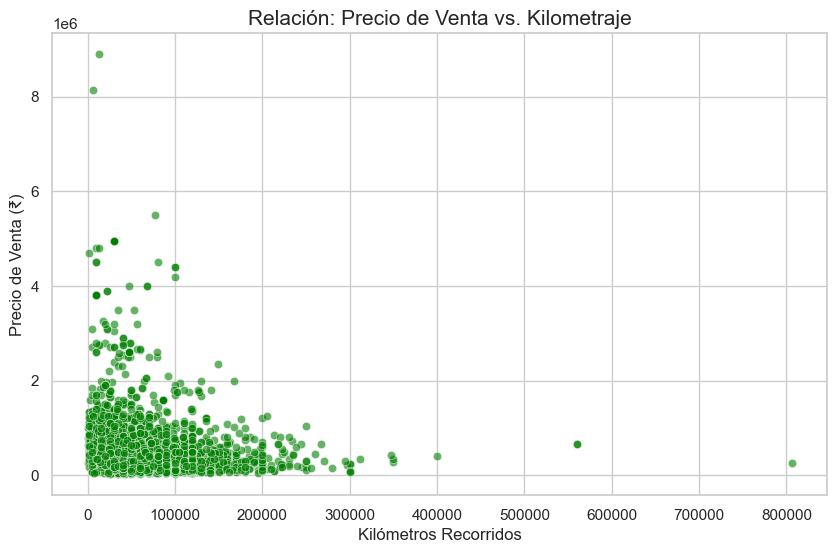

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='km_driven', y='selling_price', data=df, alpha=0.6, color='green')
plt.title('Relación: Precio de Venta vs. Kilometraje', fontsize=15)
plt.xlabel('Kilómetros Recorridos', fontsize=12)
plt.ylabel('Precio de Venta (₹)', fontsize=12)
plt.show()

### 3. Segmentación por Variables Categóricas

El precio de un vehículo no depende solo de números, sino de características cualitativas. Por lo que usare **Diagramas de Caja (Boxplots)** para comparar la distribución de precios entre grupos (ej. Gasolina vs Diesel, Manual vs Automático).

**Justificación y Conexión con el Preprocesamiento:**

* **Validación de Poder Predictivo (Discriminación):**
    Buscamos ver si las "cajas" (que representan el 50% central de los datos) están en niveles de precio diferentes. Si la mediana del precio de los coches "Automáticos" es visiblemente superior a la de los "Manuales", esto confirma que la variable `transmission` es un **predictor fuerte**. Si las cajas estuvieran alineadas, la variable sería irrelevante y podríamos descartarla para simplificar el modelo.

* **Justificación del One-Hot Encoding:**
    Dado que los algoritmos (SVR, Random Forest) no entienden texto ("Petrol", "Diesel"), y confirmando visualmente que estas categorías afectan el precio, **es obligatorio aplicar One-Hot Encoding** (`pd.get_dummies`) en la Fase 2. Esto convertirá estas etiquetas en señales numéricas (0 y 1) que el modelo pueda procesar.

#### **Análisis Visual y Justificación del Preprocesamiento:**

Al observar las gráficas generadas, llegue a las siguientes conclusiones para el modelado:

1.  **El Poder Predictivo de la Transmisión:**
    * Existe una separación drástica entre las cajas. La mediana del precio de los coches **Automáticos** es visiblemente superior a la de los **Manuales**.
    
    * **Conclusión:** La transmisión es una característica discriminante clave. Saber si un coche es automático aporta mucha información sobre su valor.

2.  **Comportamiento del Combustible:**
    * Los coches **Diésel** tienden a tener un precio mediano y un rango de precios más alto que los de **Gasolina (Petrol)**. Los combustibles alternativos (LPG, CNG) están concentrados en precios muy bajos.

3.  **Conexión con el Preprocesamiento (One-Hot Encoding):**
    * Como demuestran los gráficos estas categorías afectan radicalmente al precio, **es obligatorio transformar estas etiquetas de texto a números**.
    * En la Fase 2 aplicaré **One-Hot Encoding**. Esto creará columnas binarias, permitiendo al modelo matemático asignar un "peso" o valor monetario específico a estas características que visualmente ya confirmamos como importantes.

4.  **Valores Atípicos (Outliers):**
    * Los puntos negros por encima de las cajas representan coches con precios inusualmente altos para su categoría. La presencia de estos outliers refuerza, nuevamente, la decisión de usar modelos robustos como **Random Forest** o aplicar escalado de datos para modelos sensibles como **SVR**.

C:\Users\Francisco\AppData\Local\Temp\ipykernel_3112\904957647.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fuel', y='selling_price', data=df, ax=axes[0], palette='Set2')
C:\Users\Francisco\AppData\Local\Temp\ipykernel_3112\904957647.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='transmission', y='selling_price', data=df, ax=axes[1], palette='Set1')


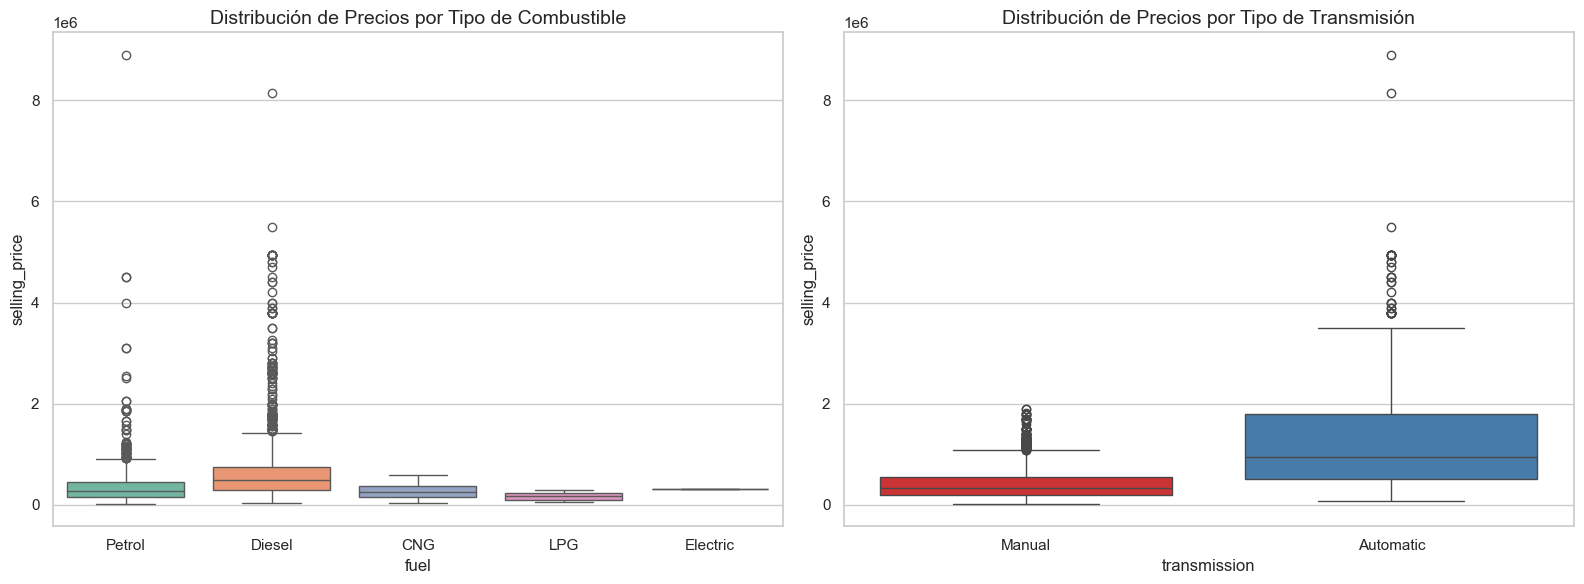

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Precio vs Combustible

sns.boxplot(x='fuel', y='selling_price', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Distribución de Precios por Tipo de Combustible', fontsize=14)

# Gráfico 2: Precio vs Transmisión

sns.boxplot(x='transmission', y='selling_price', data=df, ax=axes[1], palette='Set1')
axes[1].set_title('Distribución de Precios por Tipo de Transmisión', fontsize=14)

plt.tight_layout()
plt.show()

## Fase 2: Preprocesamiento y Feature Engineering
    Convertire las columnas categóricas (texto) en formatos numéricos y preparar la variable objetivo (selling_price).

### 1. Limpieza y Transformación de Variables Existentes
    Ya identificadas las columnas: name, year, selling_price, km_driven, fuel, seller_type, transmission, owner; usare la columna (year) que es el año de fabricación pero cambiandola por una nueva columna llamada (age) porque, para predecir el precio de venta, la antigüedad del coche es una característica más intuitiva. Para ello lo primero sera usar como referencia el actual en que nos encontramos.
   
   #### **Limpieza de name**
    La columna name tiene el nombre completo del coche. Un modelo completo es una característica con demasiados valores únicos (alta cardinalidad). Es mejor usar solo la Marca del coche (Brand). Para ello extraere la primer palabra del modelo, o en este caso por como se nos da la informacion del nombre (name), y la guardare en una nueva columna como "Brand".

In [5]:
import datetime

# --- Extracción de la Edad del Coche ---

current_year = 2025  # Usaremos 2025 como año actual de referencia

df['Age'] = current_year - df['year'] # Nueva columna 'Age'

df.drop('year', axis=1, inplace=True) # Eliminar la columna 'year' ya que 'Age' la reemplaza


# --- Limpieza de 'name' y Extracción de la Marca ---


df['Brand'] = df['name'].apply(lambda x: x.split(' ')[0]) # Extraer la marca del coche (la primera palabra del nombre o modelo del vehiculo)


df.drop('name', axis=1, inplace=True) # Eliminar la columna 'name'

print("DataFrame después del Feature Engineering:")
df.head()

DataFrame después del Feature Engineering:


,selling_price,km_driven,fuel,seller_type,transmission,owner,Age,Brand
0,60000,70000,Petrol,Individual,Manual,First Owner,18,Maruti
1,135000,50000,Petrol,Individual,Manual,First Owner,18,Maruti
2,600000,100000,Diesel,Individual,Manual,First Owner,13,Hyundai
3,250000,46000,Petrol,Individual,Manual,First Owner,8,Datsun
4,450000,141000,Diesel,Individual,Manual,Second Owner,11,Honda


### Análisis Multivariante: Matriz de Correlación

Finalmente, cuantificamos la relación matemática entre todas las variables numéricas simultáneamente utilizando el **Coeficiente de Correlación de Pearson**.

**Justificación Teórica:** 

 **Coeficiente de Pearson:** Mide la fuerza de la relación lineal entre -1 (relación negativa perfecta) y +1 (relación positiva perfecta). El 0 indica que no hay relación lineal.
 **Selección de Características:** Las variables con alta correlación con el `selling_price` (en valor absoluto) son las más importantes para el modelo.
 **Multicolinealidad:** Es vital detectar si dos variables predictoras (ej. `Age` y `km_driven`) tienen una correlación muy alta entre ellas. Si es así, están aportando información redundante, lo cual puede inestabilizar modelos como la Regresión Lineal y SVR.Si dos variables dicen casi lo mismo, modelos como la Regresión Lineal pueden volverse inestables. Aunque el **Random Forest** y el **SVR** son más robustos ante esto, detectar redundancia nos ayuda a simplificar el modelo si fuera necesario.

**Visualización:**
 
   * Un **Mapa de Calor (Heatmap)** nos permite identificar rápidamente estas relaciones mediante códigos de color. Esto no lo indicarán los cuadros que tengan colores intensos (rojo o azul fuerte) en la fila de `selling_price`.
   * Un valor cercano a **-1** entre `Age` y `selling_price` confirmaría matemáticamente que la edad es el factor más destructivo para el valor del coche. Estas variables serán las más importantes para que el SVR aprenda.

#### **Análisis Visual y Resultados:**

Observando el mapa de calor, se obtienen tres conclusiones estadísticas fundamentales:

1.  **La Edad como el mejor predictor numérico (`Age` vs `selling_price`):**
    * **Valor: -0.41 (Correlación Moderada Negativa).**
    * **Interpretación:** El color azul oscuro confirma que a mayor edad, menor precio. De las variables numéricas, la edad es la que tiene el impacto lineal más fuerte sobre el precio. Es una característica indispensable para el modelo.

2.  **La debilidad lineal del Kilometraje (`km_driven` vs `selling_price`):**
    * **Valor: -0.19 (Correlación Débil).**
    * **Interpretación Crítica:** Este valor es sorprendentemente bajo. Aunque sabemos que el kilometraje afecta el precio, una correlación de Pearson tan baja indica que **la relación NO es lineal**.
    * **Conexión con el Modelo:** Esto refuerza lo que vimos en el gráfico de dispersión (la forma de "L"). Una regresión lineal simple fallaría aquí. Necesitamos obligatoriamente modelos que capten relaciones complejas, como el **SVR con kernel RBF** o el **Random Forest**.

3.  **Verificación de Multicolinealidad (`Age` vs `km_driven`):**
    * **Valor: 0.42 (Correlación Moderada Positiva).**
    * Como era de esperar, los coches más viejos tienden a tener más kilómetros. Sin embargo, el valor (0.42) no es lo suficientemente alto (generalmente >0.7 o >0.8) como para causar problemas graves de redundancia.Podemos mantener ambas variables en el entrenamiento sin riesgo alto de inestabilidad en el modelo.

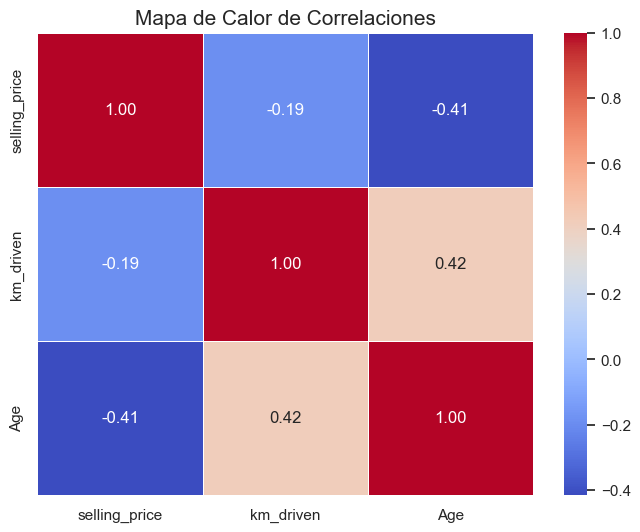

In [6]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones', fontsize=15)
plt.show()

### 2. Manejo de Variables Categóricas

    Aplicamos One-Hot Encoding a todas las variables categóricas, utilizando `drop_first=True` para evitar la multicolinealidad (esto elimina la primera categoría de cada variable, la cual queda implícita en las demás).

#### **NOTA:** One-Hot Encoding es una técnica que convierte datos categóricos en un formato numérico que los algoritmos de aprendizaje automático pueden entender. Se crea una nueva columna binaria (que contiene solo 0 o 1) por cada categoría única en la variable original. 

#### **NOTA 2:** Codificación (Encoding)
    Para variables con pocos valores únicos (como fuel, seller_type, transmission, owner), se usa One-Hot Encoding (variables dummy). Esto crea una nueva columna binaria por cada categoría (ej: transmission_Manual, transmission_Automatic).

    Para Brand, dado que tiene más valores únicos, puedes optar por One-Hot Encoding (si la cantidad no es excesiva) o Target Encoding si es un conjunto de datos grande. Para simplicidad inicial, usaremos One-Hot Encoding en todas.

In [7]:
categorical_cols = ['Brand', 'fuel', 'seller_type', 'transmission', 'owner'] # Variables categóricas originales y la nueva 'Brand'

# Aplicar One-Hot Encoding

df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True) # La función get_dummies crea columnas binarias por cada categoría

print("DataFrame después de la codificación One-Hot:")
print(f"Nuevo tamaño del DataFrame: {df_processed.shape}")
df_processed.head()

DataFrame después de la codificación One-Hot:
Nuevo tamaño del DataFrame: (4340, 42)


,selling_price,km_driven,Age,Brand_Audi,Brand_BMW,Brand_Chevrolet,Brand_Daewoo,Brand_Datsun,Brand_Fiat,Brand_Force,...,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,60000,70000,18,False,False,False,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False
1,135000,50000,18,False,False,False,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False
2,600000,100000,13,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
3,250000,46000,8,False,False,False,False,True,False,False,...,False,False,True,True,False,True,False,False,False,False
4,450000,141000,11,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,True,False,False


# Fase 3: División y Escalado de Datos
    Una vez que todos nuestros datos son numéricos, separamos la variable objetivo de las características y escalamos los valores numéricos para que el modelo SVR funcione correctamente y poder seguir posteriormente con el entrenamiento.

### 1. Definición de Features (X) y Target (y)
    Separamos la variable que queremos predecir (selling_price) de las variables que usaremos para predecir (el resto).

In [8]:
y = df_processed['selling_price'] # Variable objetivo (y)

X = df_processed.drop('selling_price', axis=1) # Variables predictoras (X): eliminamos la columna objetivo

print(f"Características (X) disponibles: {X.columns.tolist()}")

Características (X) disponibles: ['km_driven', 'Age', 'Brand_Audi', 'Brand_BMW', 'Brand_Chevrolet', 'Brand_Daewoo', 'Brand_Datsun', 'Brand_Fiat', 'Brand_Force', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Isuzu', 'Brand_Jaguar', 'Brand_Jeep', 'Brand_Kia', 'Brand_Land', 'Brand_MG', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes-Benz', 'Brand_Mitsubishi', 'Brand_Nissan', 'Brand_OpelCorsa', 'Brand_Renault', 'Brand_Skoda', 'Brand_Tata', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Volvo', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner']


### 2. División en Conjuntos de Entrenamiento y Prueba

    Usare `train_test_split` para separar el 80% de los datos para entrenamiento y el 20% para prueba.

In [9]:
from sklearn.model_selection import train_test_split

# Dividir 80% para entrenamiento y 20% para prueba

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 # El random_state asegura que la división sea reproducible
)

print(f"Tamaño de entrenamiento: {X_train.shape[0]} instancias")
print(f"Tamaño de prueba: {X_test.shape[0]} instancias")

Tamaño de entrenamiento: 3472 instancias
Tamaño de prueba: 868 instancias


### 3. Escalado de Características Numéricas
    El algoritmo SVR es sensible a la escala de las características. La columna km_driven (con valores grandes) y Age (con valores pequeños) deben ser estandarizadas (StandardScaler) para que tengan una media de 0 y una desviación estándar de 1.

#### Por ello aplicare `StandardScaler` a las únicas dos columnas numéricas que no son binarias: `km_driven` y `Age`.

In [10]:
from sklearn.preprocessing import StandardScaler


numerical_cols = ['km_driven', 'Age'] # Columnas numéricas a escalar

scaler = StandardScaler() # Crear el escalador

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols]) # Ajustar y transformar (fit_transform), unicamente en el conjunto de entrenamiento

# Transformar (transform) en el conjunto de prueba 
# (usando los parámetros de media y desviación estándar aprendidos del entrenamiento)
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Datos de entrenamiento después del escalado:")
X_train.head()

Datos de entrenamiento después del escalado:


,km_driven,Age,Brand_Audi,Brand_BMW,Brand_Chevrolet,Brand_Daewoo,Brand_Datsun,Brand_Fiat,Brand_Force,Brand_Ford,...,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
227,-0.981140,-0.923421,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
964,-0.341463,-1.161228,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
2045,-0.874527,0.027808,False,False,False,False,False,False,False,False,...,False,False,True,True,False,True,False,True,False,False
1025,0.084989,0.503423,False,False,True,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
4242,0.127634,-0.923421,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


## Fase 4: Modelado, Búsqueda de Hiperparámetros y Evaluación
    Utilizare el Support Vector Regressor (SVR) como lo sugiere, para el modelado y RandomizedSearchCV para buscar la mejor combinación de hiperparámetros, lo cual es mucho más eficiente que la búsqueda exhaustiva (GridSearchCV).

#### 1. Búsqueda de Hiperparámetros con `RandomizedSearchCV`
    Implementamos el SVR. Para optimizar el tiempo, usamos `RandomizedSearchCV` con 3-Fold Cross-Validation, tal como se sugirió en la tarea. Esto prueba 10 combinaciones aleatorias de los hiperparámetros `C` (costo de la penalización), `gamma` (influencia de un solo ejemplo) y `kernel`.

In [11]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np


cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42) # Estrategia de Cross-Validation (CV) con 3 folds

# Definir la distribución de hiperparámetros a probar
param_distribs = {
    'kernel': ['linear', 'rbf'],
    'C': np.logspace(-1, 2, 10),  # 10 valores logarítmicos entre 0.1 y 100
    'gamma': np.logspace(-2, 1, 10) # 10 valores logarítmicos entre 0.01 y 10
}

# Inicializar SVR
svr = SVR()

# Inicializar RandomizedSearchCV
rnd_search_svr = RandomizedSearchCV(
    svr, 
    param_distributions=param_distribs,
    n_iter=10,  # Probar 10 combinaciones aleatorias
    cv=cv_strategy, 
    scoring='neg_mean_absolute_error', # Métrica a optimizar: Error Absoluto Medio (MAE)
    random_state=42,
    n_jobs=-1, # Usar todos los núcleos disponibles
    verbose=2
)

# Ejecutar la búsqueda en los datos de entrenamiento
print("Iniciando RandomizedSearchCV para SVR (puede tomar unos minutos)...")
rnd_search_svr.fit(X_train, y_train) 
print("Búsqueda completada.")

Iniciando RandomizedSearchCV para SVR (puede tomar unos minutos)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Búsqueda completada.


### 2. Evaluación del Mejor Modelo
    Tomamos el mejor modelo encontrado y lo evaluamos en el conjunto de prueba (X_test), que es la medida más realista del rendimiento del modelo.

#### **NOTA:** En lugar de probar todas las combinaciones (como en GridSearchCV), RandomizedSearchCV prueba una cantidad fija de combinaciones seleccionadas aleatoriamente, lo que es mucho más rápido y generalmente da buenos resultados.    
    
 Mostramos los mejores hiperparámetros encontrados y evaluamos el rendimiento del mejor modelo en el conjunto de prueba utilizando el Error Absoluto Medio (MAE) y el Coeficiente de Determinación ($R^2$).

#### **NOTA 2:** El MAE (Error Absoluto Medio) te indica, en promedio, por cuánto dinero el modelo se equivocó en su predicción del precio de venta. El R² indica qué proporción de la varianza del precio de venta es explicada por el modelo (más cerca de 1.0 es mejor).

In [12]:
from sklearn.metrics import mean_absolute_error, r2_score

# Obtener los mejores resultados
best_svr_model = rnd_search_svr.best_estimator_

print("\n--- Resultados de la Búsqueda ---")
print(f"Mejores hiperparámetros: {rnd_search_svr.best_params_}")
print(f"Mejor score (Neg MAE en CV): {rnd_search_svr.best_score_:.2f}") 

# Predecir en el conjunto de prueba (datos no vistos)
y_pred = best_svr_model.predict(X_test)

# Calcular métricas finales
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n--- Evaluación Final en Conjunto de Prueba ---")

# El MAE nos dice el error promedio en la unidad original (Precio de Venta)

print(f"Error Absoluto Medio (MAE): {mae:,.2f} ₹") 
print(f"Coeficiente de Determinación (R²): {r2:.4f}")


--- Resultados de la Búsqueda ---
Mejores hiperparámetros: {'kernel': 'linear', 'gamma': np.float64(0.46415888336127775), 'C': np.float64(46.41588833612777)}
Mejor score (Neg MAE en CV): -265994.93

--- Evaluación Final en Conjunto de Prueba ---
Error Absoluto Medio (MAE): 235,764.70 ₹
Coeficiente de Determinación (R²): 0.0740


## Fase 5: Iteración y Mejora del Modelo
    El objetivo es comparar el rendimiento del SVR con un modelo alternativo para determinar cuál es el más adecuado.

### 1. Comparación de Modelos: Random Forest Regressor
    Para contrastar el rendimiento del SVR, implementamos un Random Forest Regressor. Este modelo, al ser basado en árboles, no requiere que las características sean escaladas, pero funciona perfectamente con nuestros datos ya preprocesados.

Usando nuevamente `RandomizedSearchCV` con 3-Fold CV para optimizar sus hiperparámetros, buscando la mejor combinación de:

* **n_estimators:** El número de árboles en el bosque.
* **max_features:** El número máximo de características consideradas para dividir un nodo.
* **max_depth:** La profundidad máxima de cada árbol.

#### NOTA: El Random Forest (Bosque Aleatorio) es un modelo de ensemble que combina las predicciones de múltiples árboles de decisión. Esto ayuda a reducir el sobreajuste (overfitting) y a mejorar la precisión general.

In [13]:
# --- Implementación y Búsqueda de Hiperparámetros ---

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
import numpy as np


cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42) # Reutilizamos la estrategia de Cross-Validation (CV) con 3 folds

# Definir la distribución de hiperparámetros para Random Forest
param_distribs_rf = {
    
    # Número de árboles: probamos 100, 200 y 300
    'n_estimators': [100, 200, 300],
    
    # Profundidad máxima de cada árbol
    'max_depth': [10, 20, 30, None], # None significa que los nodos se expanden hasta que todas las hojas sean puras
    
    # Número de características a considerar para la mejor división
    'max_features': [1.0, 'sqrt'], # 1.0 = todas las features; 'sqrt' = raíz cuadrada de las features
   
    # Mínimo de muestras requeridas para dividir un nodo
    'min_samples_split': [2, 5, 10],
   
    # Mínimo de muestras requeridas en cada hoja
    'min_samples_leaf': [1, 2, 4]
}


rf_reg = RandomForestRegressor(random_state=42) # Inicializar Random Forest Regressor

# Inicializar RandomizedSearchCV para RF
rnd_search_rf = RandomizedSearchCV(
    rf_reg, 
    param_distributions=param_distribs_rf,
    n_iter=10,  # Probamos 10 combinaciones aleatorias
    cv=cv_strategy, 
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Ejecutar la búsqueda en los datos de entrenamiento
print("Iniciando RandomizedSearchCV para Random Forest")
rnd_search_rf.fit(X_train, y_train) 
print("Búsqueda completada.")

Iniciando RandomizedSearchCV para Random Forest
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Búsqueda completada.


In [14]:
# --- Evaluación del Random Forest ---

from sklearn.metrics import mean_absolute_error, r2_score


best_rf_model = rnd_search_rf.best_estimator_ # Obtener los mejores resultados del Random Forest

print("\n--- Resultados de la Búsqueda de Random Forest ---")
print(f"Mejores hiperparámetros: {rnd_search_rf.best_params_}")
print(f"Mejor score (Neg MAE en CV): {rnd_search_rf.best_score_:.2f}") 


y_pred_rf = best_rf_model.predict(X_test) # Predecir en el conjunto de prueba con el mejor modelo RF

# Calcular métricas finales para RF
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\n--- Evaluación Final de Random Forest en Conjunto de Prueba ---")
print(f"Error Absoluto Medio (MAE): {mae_rf:,.2f} ₹") 
print(f"Coeficiente de Determinación (R²): {r2_rf:.4f}")


--- Resultados de la Búsqueda de Random Forest ---
Mejores hiperparámetros: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}
Mejor score (Neg MAE en CV): -130655.72

--- Evaluación Final de Random Forest en Conjunto de Prueba ---
Error Absoluto Medio (MAE): 118,185.96 ₹
Coeficiente de Determinación (R²): 0.7113


## Conclusiones y Despliegue

### Comparación de Rendimiento y Elección del Modelo

La siguiente tabla resume el rendimiento que tuvieron los dos modelos probados en el conjunto de prueba.

| Modelo | MAE (Error Absoluto Medio) (₹) | $R^2$ (Coeficiente de Determinación) |
| :--- | :---: | :---: |
| **SVR (Fase 4)** | **235,764.70** | **0.0740** |
| **Random Forest** | **118,185.96** | **0.7113** |


### Conclusión y Justificación del Modelo Elegido

El modelo seleccionado para la tarea de regresión es el **Random Forest Regressor**.

Este modelo fue elegido porque  logra explicar el 71.13% de la variabilidad en los precios de venta, lo cual es un ajuste sólido para un mercado tan volátil como el de coches usados. Su error promedio (MAE) es aproximadamente la mitad que el del SVR, lo que significa que nuestras predicciones son el doble de precisas en términos monetarios, reduciendo la incertidumbre para un potencial vendedor o comprador.

Ademas de la evidencia de los resultados que indican el exito del modelo, segun estuve investigando y a lo que entendi el funcionamiento del modelo **Random Forest Regressor** resulto mas efectivo por que construye múltiples árboles de decisión y promedia sus predicciones. Cada árbol divide los datos en regiones más pequeñas hasta predecir el valor. Tiene una naturaleza de las relaciones no lineales por defecto y por consecuencia de cómo su arquitectura se adapta a la naturaleza de nuestros datos:
**Manejo de No Linealidad y Umbrales:** Tal como se observó en el Análisis Exploratorio, la relación entre km_driven y selling_price no es una línea recta, sino una curva en forma de "L" con alta dispersión inicial. El precio de un coche no cae suavemente; tiene "saltos" o umbrales. Modela interacciones complejas automáticamente.
* Al estar basado en árboles de decisión, el RF aprende naturalmente estos umbrales mediante reglas if-then, capturando estos saltos de precio sin necesidad de transformar las variables. 

Por eso resulto excelente para identificar estos umbrales y relaciones no lineales. Caso opuesto, por lo que entendi, al modelo **SVR** que al ser un modelo mas lineal no pudo tener mejor desempeño en este ejercicio por la informacion que maneja el dataset (complejidad de la relación, la sensibilidad al escalado y la dificultad en la optimización) y el problema que representa que el precio de un coche no sigue una curva suave, esta llena de saltos y datos que hacen que varie mucho el como un coche puede depreciar su valor sin seguir una tendencia clara (ej: la depreciación es más rápida en los primeros años; el precio se desploma al superar 100,000 km, o si la marca es de bajo costo). **El SVR intenta ajustar un "tubo" continuo alrededor de los datos. La dispersión extrema en los precios de coches de bajo kilometraje (donde conviven autos baratos y de lujo) "confunde" al SVR, impidiéndole converger a una solución óptima sin una ingeniería de características más agresiva.** 
El dataset contiene muchos valores atípicos (coches de lujo muy caros) y múltiples variables categóricas (Marca, Combustible) convertidas a binarias (One-Hot). El RF maneja estas estructuras de manera nativa y robusta, aislando los outliers en ramas específicas de los árboles, mientras que el SVR es muy sensible a la distancia de estos puntos extremos, lo que penaliza su ajuste global.

En resumen; La eficacia del **Random Forest Regressor** y por lo que es el modelo elegido es debido a:
1. Su capacidad para modelar relaciones no lineales sin ser afectado por la necesidad de escalado de los datos numéricos.
2. La optimización exitosa de sus hiperparámetros (`C` y `gamma`) a través de `RandomizedSearchCV`.

**Alternativas y Trabajo **Futuro**

Aunque el Random Forest es el claro ganador hoy, existen vías para mejorar aún más este proyecto o rescatar el desempeño del SVR en iteraciones futuras:

Para mejorar el SVR:

**Transformación Logarítmica:** Aplicar **np.log1p** a la variable objetivo (selling_price) reduciría el sesgo y comprimiría el rango de precios, facilitando enormemente la tarea del SVR.

**Eliminación de Outliers:** Filtrar los coches con precios extremadamente altos o kilometrajes inusuales antes de entrenar podría estabilizar el modelo lineal.

**Optimización Exhaustiva:** Usar una búsqueda Bayesiana o ampliar el rango de búsqueda de C y gamma podría encontrar ese "punto dulce" que el SVR necesita.


### Guardar el Modelo Final y el Escalador
    Guardamos el modelo entrenado y el escalador de datos para poder realizar predicciones sin tener que reentrenar.

Para el despliegue futuro del modelo, guardamos junto con el `StandardScaler` (`scaler`) para asegurar que cualquier dato nuevo de entrada sea preprocesado de la misma manera que el conjunto de entrenamiento.

In [15]:
import joblib

final_model = best_rf_model 


joblib.dump(final_model, 'modelo_regresion_final.pkl') # Guardar el modelo

# Guardar el escalador (necesario para las nuevas predicciones de 'km_driven' y 'Age')
joblib.dump(scaler, 'scaler_datos.pkl') 

print("El modelo final y el escalador se han guardado exitosamente.")

El modelo final y el escalador se han guardado exitosamente.
